All yearly datasets loaded successfully.

Dataset Shape:
(26007, 12)

Column Names:
Index(['Material', 'Material Description', 'SLoc', 'Quantity', 'Pstng Date',
       'Tmax', 'Tmin', 'RH', 'Delta_T', 'Month', 'Season', 'Region'],
      dtype='str')

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 26007 entries, 0 to 26006
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Material              26007 non-null  int64  
 1   Material Description  26007 non-null  str    
 2   SLoc                  26007 non-null  int64  
 3   Quantity              26007 non-null  int64  
 4   Pstng Date            26007 non-null  str    
 5   Tmax                  25988 non-null  float64
 6   Tmin                  25988 non-null  float64
 7   RH                    25988 non-null  float64
 8   Delta_T               25988 non-null  float64
 9   Month                 26007 non-null  int64  
 10  Season              

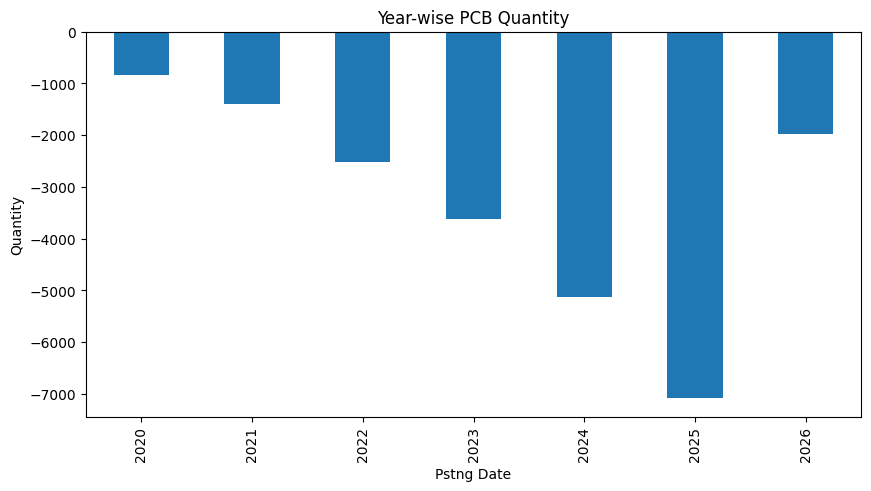

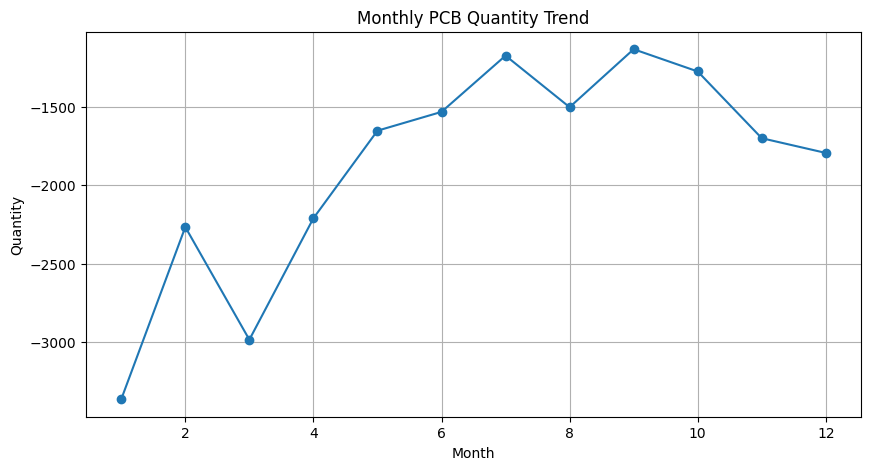

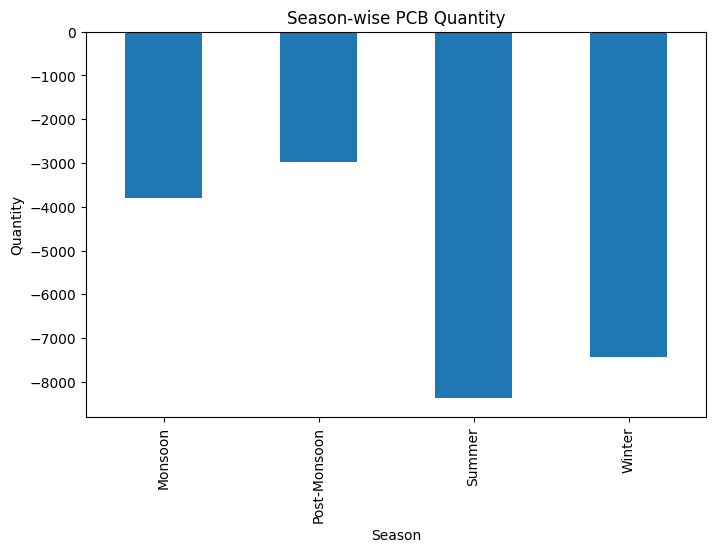

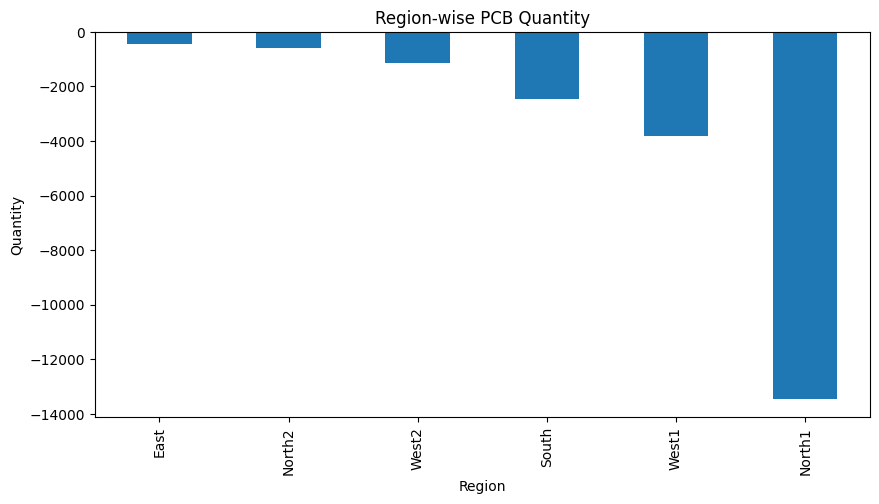

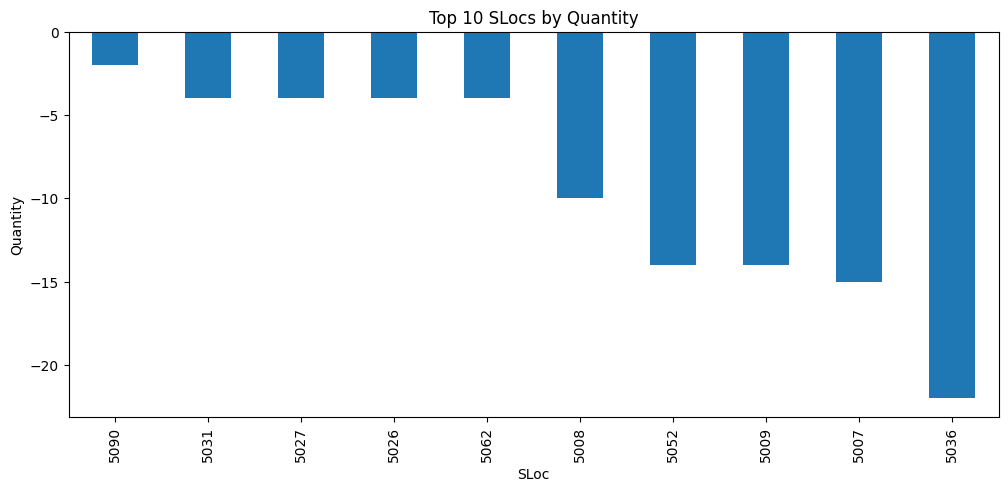

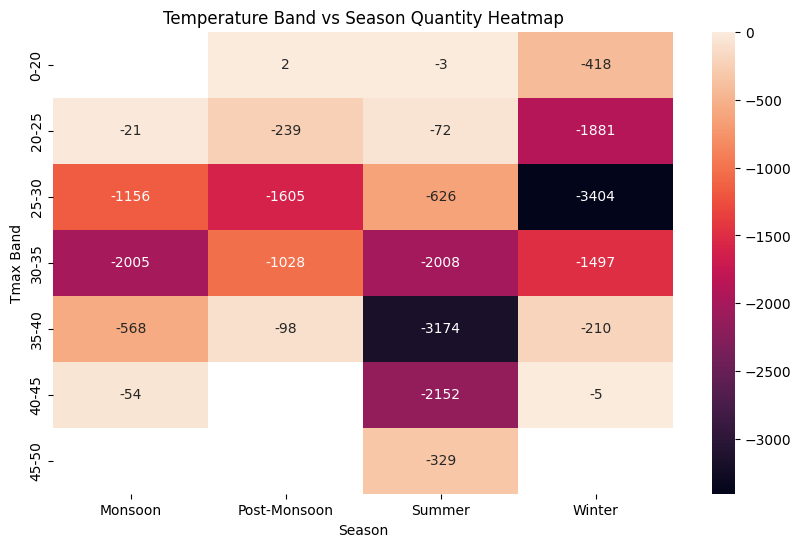

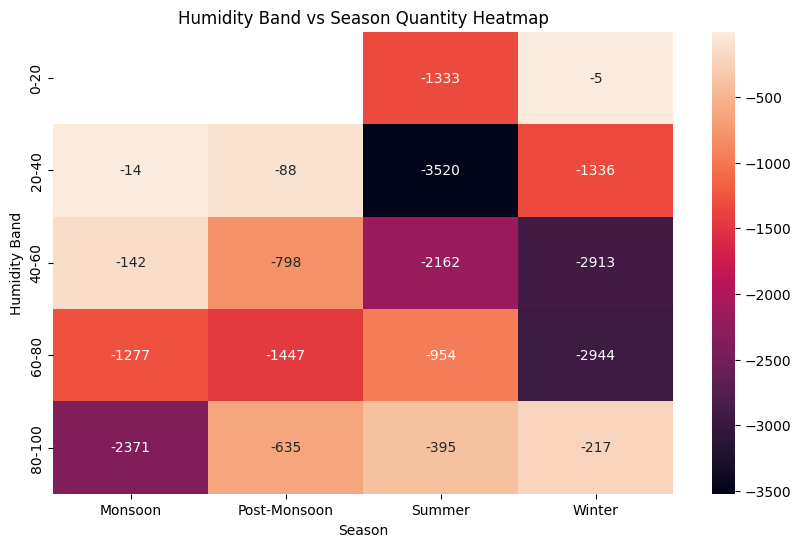

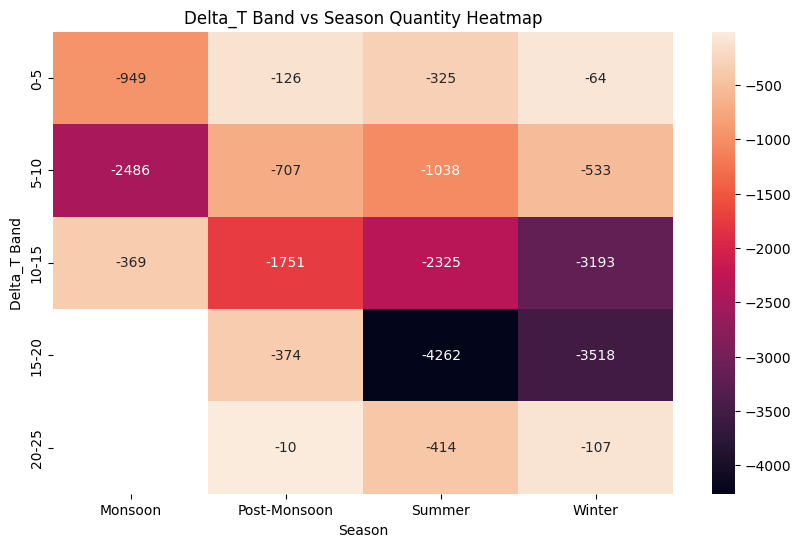

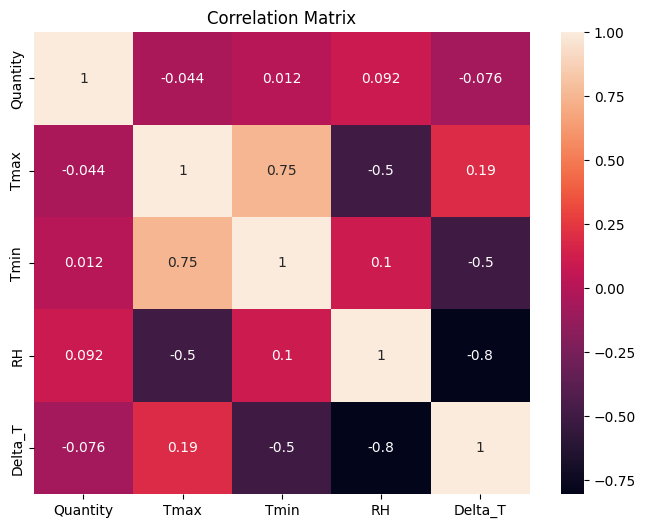


Top Hotspots:
Region  SLoc
East    5062    -4
North2  5026    -4
        5027    -4
North1  5031    -4
West2   5008   -10
South   5052   -14
West1   5009   -14
West2   5007   -15
North1  5036   -22
East    5019   -24
        5063   -25
West2   5006   -26
East    5064   -33
North1  5028   -33
West2   5004   -36
North1  5024   -42
North2  5039   -43
South   5044   -59
West2   5014   -60
South   5049   -65
Name: Quantity, dtype: int64

High Temperature Quantity Summary:
count    2892.000000
mean       -0.878285
std         0.482541
min        -2.000000
25%        -1.000000
50%        -1.000000
75%        -1.000000
max         2.000000
Name: Quantity, dtype: float64

High Humidity Quantity Summary:
count    4816.000000
mean       -0.751246
std         0.670084
min        -4.000000
25%        -1.000000
50%        -1.000000
75%        -1.000000
max         4.000000
Name: Quantity, dtype: float64

Abnormal Quantity Records:
      Pstng Date  Region  SLoc  Quantity
35    2020-01-15  North1  5

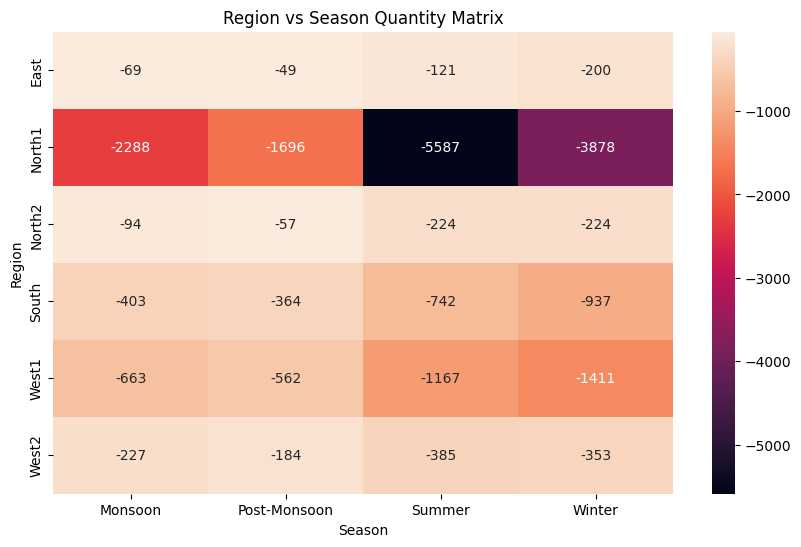


Summary tables exported successfully.

Analysis Completed Successfully.


In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os


base_path = r"C:\Users\Amey\OneDrive - College of Engineering Pune(An autonomous Institute of Govt. of Maharashtra)\Desktop\Amey\Python\100"

years = [2020, 2021, 2022, 2023, 2024, 2025, 2026]

all_data = []

for year in years:

    file_path = os.path.join(
        base_path,
        str(year),
        f"{year}_cleaned_temp_season_n_region.csv"
    )

    df = pd.read_csv(file_path)

    all_data.append(df)

final_df = pd.concat(
    all_data,
    ignore_index=True
)

print("All yearly datasets loaded successfully.")



print("\nDataset Shape:")
print(final_df.shape)

print("\nColumn Names:")
print(final_df.columns)

print("\nDataset Info:")
print(final_df.info())

print("\nMissing Values:")
print(final_df.isnull().sum())

# ============================================================
# 5. CONVERT DATE COLUMN
# ============================================================

final_df['Pstng Date'] = pd.to_datetime(
    final_df['Pstng Date']
)

# ============================================================
# 6. DESCRIPTIVE STATISTICS
# ============================================================

print("\nQuantity Statistics:")
print(final_df['Quantity'].describe())

print("\nEnvironmental Statistics:")
print(
    final_df[['Tmax', 'Tmin', 'RH', 'Delta_T']]
    .describe()
)

# ============================================================
# 7. YEAR-WISE ANALYSIS
# ============================================================

yearly_quantity = (
    final_df
    .groupby(final_df['Pstng Date'].dt.year)['Quantity']
    .sum()
)

plt.figure(figsize=(10,5))

yearly_quantity.plot(kind='bar')

plt.title("Year-wise PCB Quantity")

plt.ylabel("Quantity")

plt.show()

# ============================================================
# 8. MONTHLY TREND ANALYSIS
# ============================================================

monthly_quantity = (
    final_df
    .groupby(final_df['Pstng Date'].dt.month)['Quantity']
    .sum()
)

plt.figure(figsize=(10,5))

monthly_quantity.plot(marker='o')

plt.title("Monthly PCB Quantity Trend")

plt.xlabel("Month")

plt.ylabel("Quantity")

plt.grid()

plt.show()

# ============================================================
# 9. SEASONAL ANALYSIS
# ============================================================

seasonal_quantity = (
    final_df
    .groupby('Season')['Quantity']
    .sum()
)

plt.figure(figsize=(8,5))

seasonal_quantity.plot(kind='bar')

plt.title("Season-wise PCB Quantity")

plt.ylabel("Quantity")

plt.show()

# ============================================================
# 10. REGION-WISE ANALYSIS
# ============================================================

region_quantity = (
    final_df
    .groupby('Region')['Quantity']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

region_quantity.plot(kind='bar')

plt.title("Region-wise PCB Quantity")

plt.ylabel("Quantity")

plt.show()

# ============================================================
# 11. TOP SLOC ANALYSIS
# ============================================================

sloc_quantity = (
    final_df
    .groupby('SLoc')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,5))

sloc_quantity.plot(kind='bar')

plt.title("Top 10 SLocs by Quantity")

plt.ylabel("Quantity")

plt.show()

# ============================================================
# 12. TEMPERATURE BAND HEATMAP
# ============================================================

# Create temperature bands

final_df['Tmax_Band'] = pd.cut(

    final_df['Tmax'],

    bins=[0, 20, 25, 30, 35, 40, 45, 50],

    labels=[
        '0-20',
        '20-25',
        '25-30',
        '30-35',
        '35-40',
        '40-45',
        '45-50'
    ]
)

# Create pivot table

temp_heatmap = pd.pivot_table(

    final_df,

    values='Quantity',

    index='Tmax_Band',

    columns='Season',

    aggfunc='sum'
)

# Plot heatmap

plt.figure(figsize=(10,6))

sns.heatmap(

    temp_heatmap,

    annot=True, 

    fmt='.0f'

)

plt.title("Temperature Band vs Season Quantity Heatmap")

plt.xlabel("Season")

plt.ylabel("Tmax Band")

plt.show()

# ============================================================
# 13. HUMIDITY BAND HEATMAP
# ============================================================

# Create humidity bands

final_df['RH_Band'] = pd.cut(

    final_df['RH'],

    bins=[0, 20, 40, 60, 80, 100],

    labels=[
        '0-20',
        '20-40',
        '40-60',
        '60-80',
        '80-100'
    ]
)

# Create pivot table

humidity_heatmap = pd.pivot_table(

    final_df,

    values='Quantity',

    index='RH_Band',

    columns='Season',

    aggfunc='sum'
)

# Plot heatmap

plt.figure(figsize=(10,6))

sns.heatmap(

    humidity_heatmap,

    annot=True,

    fmt='.0f'

)

plt.title("Humidity Band vs Season Quantity Heatmap")

plt.xlabel("Season")

plt.ylabel("Humidity Band")

plt.show()

# ============================================================
# 14. DELTA_T BAND HEATMAP
# ============================================================

# Create Delta_T bands

final_df['DeltaT_Band'] = pd.cut(

    final_df['Delta_T'],

    bins=[0, 5, 10, 15, 20, 25, 30],

    labels=[
        '0-5',
        '5-10',
        '10-15',
        '15-20',
        '20-25',
        '25-30'
    ]
)

# Create pivot table

deltaT_heatmap = pd.pivot_table(

    final_df,

    values='Quantity',

    index='DeltaT_Band',

    columns='Season',

    aggfunc='sum'
)

# Plot heatmap

plt.figure(figsize=(10,6))

sns.heatmap(

    deltaT_heatmap,

    annot=True,

    fmt='.0f'

)

plt.title("Delta_T Band vs Season Quantity Heatmap")

plt.xlabel("Season")

plt.ylabel("Delta_T Band")

plt.show()

# ============================================================
# 15. CORRELATION MATRIX
# ============================================================

correlation_matrix = final_df[
    ['Quantity', 'Tmax', 'Tmin', 'RH', 'Delta_T']
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True
)

plt.title("Correlation Matrix")

plt.show()

# ============================================================
# 16. HOTSPOT DETECTION
# ============================================================

hotspots = (
    final_df
    .groupby(['Region', 'SLoc'])['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

print("\nTop Hotspots:")

print(hotspots)

# ============================================================
# 17. HIGH TEMPERATURE ANALYSIS
# ============================================================

high_temp_df = final_df[
    final_df['Tmax'] > 40
]

print("\nHigh Temperature Quantity Summary:")

print(
    high_temp_df['Quantity']
    .describe()
)

# ============================================================
# 18. HIGH HUMIDITY ANALYSIS
# ============================================================

high_humidity_df = final_df[
    final_df['RH'] > 80
]

print("\nHigh Humidity Quantity Summary:")

print(
    high_humidity_df['Quantity']
    .describe()
)

# ============================================================
# 19. ABNORMAL QUANTITY DETECTION
# ============================================================

threshold = (
    final_df['Quantity']
    .mean()
    + 2 * final_df['Quantity'].std()
)

abnormal_df = final_df[
    final_df['Quantity'] > threshold
]

print("\nAbnormal Quantity Records:")

print(
    abnormal_df[
        ['Pstng Date', 'Region', 'SLoc', 'Quantity']
    ]
)

# ============================================================
# 20. REGION VS SEASON MATRIX
# ============================================================

region_season = pd.pivot_table(

    final_df,

    values='Quantity',

    index='Region',

    columns='Season',

    aggfunc='sum'
)

plt.figure(figsize=(10,6))

sns.heatmap(
    region_season,
    annot=True,
    fmt='.0f'
)

plt.title("Region vs Season Quantity Matrix")

plt.show()

# ============================================================
# 21. SAVE SUMMARY TABLES
# ============================================================

yearly_quantity.to_csv(
    os.path.join(base_path, "yearly_summary.csv")
)

monthly_quantity.to_csv(
    os.path.join(base_path, "monthly_summary.csv")
)

region_quantity.to_csv(
    os.path.join(base_path, "region_summary.csv")
)

seasonal_quantity.to_csv(
    os.path.join(base_path, "season_summary.csv")
)

print("\nSummary tables exported successfully.")

# ============================================================
# 22. FINAL INSIGHTS
# ============================================================

print("\nAnalysis Completed Successfully.")